# **Project Name**    - Phonepe Transaction Insights



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Hasini Pulavarthi


# **Project Summary -**

The rapid growth of digital payment platforms has transformed the way financial transactions are conducted, making it essential to analyze user behavior, transaction trends, and regional adoption patterns. This project focuses on exploring and visualizing transaction data from the PhonePe Pulse GitHub repository to derive meaningful insights that can support data-driven decision-making. The primary objective is to build an end-to-end data analytics pipeline that extracts, processes, analyzes, and presents transaction data through an interactive dashboard.

The project begins with data extraction from the PhonePe Pulse repository, which provides structured JSON files containing information about transactions, users, and insurance categories across different states, districts, and time periods. These datasets are systematically accessed and processed using Python. The JSON data is parsed and transformed into structured tabular formats using the Pandas library, enabling efficient manipulation and analysis. Key attributes such as state, year, quarter, transaction type, transaction count, and transaction amount are extracted and organized for further processing.

Following data transformation, the cleaned data is stored in a relational database using SQL. This step ensures efficient storage, retrieval, and querying of large datasets. Structured tables are created to represent aggregated transaction data, enabling the use of SQL queries to perform operations such as grouping, filtering, and ranking. Through SQL, the project identifies top-performing states, analyzes transaction growth over time, and evaluates the distribution of transaction categories.

The analytical phase involves performing exploratory data analysis (EDA) to uncover patterns and trends within the dataset. Various metrics are computed, including total transaction volume, transaction value, and growth rates across different regions and time periods. The analysis highlights key insights such as the dominance of certain states in digital transactions, variations in transaction categories, and trends in user engagement over time. These insights provide a deeper understanding of how digital payment adoption varies geographically and temporally.

To effectively communicate the findings, an interactive dashboard is developed using Streamlit and Plotly. The dashboard allows users to dynamically explore the data through visualizations such as bar charts, line graphs, and pie charts. Users can filter data based on state, year, and transaction type, enabling a customized and intuitive exploration experience. The dashboard serves as a powerful tool for visual storytelling, making complex data accessible and easy to interpret.

Overall, this project demonstrates the complete workflow of a data analytics solution, from raw data extraction to insight generation and visualization. It highlights the importance of data-driven approaches in understanding financial systems and user behavior. The insights derived from this analysis can be valuable for businesses and policymakers to improve digital payment strategies, enhance user engagement, and identify growth opportunities. By combining Python, SQL, and Streamlit, the project showcases practical skills in data engineering, analysis, and visualization, making it a comprehensive and impactful analytical application.

# **GitHub Link -**

https://github.com/HasiniPulavarthi/Phonepe-Transaction-Insight.git

# **Problem Statement**


With the increasing adoption of digital payment platforms like PhonePe, there is a vast amount of transaction data being generated across different regions and time periods. However, this data is often unstructured and difficult to interpret without proper analysis. Understanding patterns in transaction volume, user engagement, and regional performance is essential for businesses to make informed decisions, optimize services, and enhance user experience.

The challenge is to efficiently extract, process, and analyze this large-scale transaction data to uncover meaningful insights such as top-performing states, growth trends over time, and popular transaction categories. Additionally, there is a need to present these insights in a clear and interactive manner to support better decision-making.

#### **Define Your Business Objective?**

The primary objective of this project is to analyze PhonePe transaction data to identify key trends, patterns, and performance metrics across different regions and time periods. The project aims to provide actionable insights such as identifying high-growth regions, understanding user behavior, and evaluating the popularity of various transaction categories.

By developing an interactive dashboard, the project enables users to easily explore the data and gain insights that can help improve business strategies, enhance customer engagement, and support data-driven decision-making in digital payment systems.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
!pip install streamlit

In [2]:
# Import Libraries
import os
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import sqlite3
import streamlit as st

### Dataset Loading

In [3]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
print(os.listdir("/content/drive/MyDrive"))

['invoice.pdf', '12th.pdf', 'Scholarship form.gdoc', 'DOC-20240326-WA0062..pdf', 'INTER TC.pdf', 'INTER STUDY.pdf', 'COMMUNITY,NATIVE and DATE OF BIRTH CERTIFICATE .pdf', 'DOC-20240806-WA0014.pdf', 'vineyard.pdf', 'Cool Bizz(25 sep).docx.pdf', 'Inspection reports', 'NA23B018(RESUME).docx - Google Docs.pdf', 'NA23B018(RESUME).docx', 'intershipstudio', 'Colab Notebooks', 'noncore(ml).pdf', 'mediumtopics.gdoc', 'Untitled form.gform', 'mediumarticles.gdoc', 'Untitled document (2).gdoc', 'Chatpata_CMGF_Finalised_menu_pricising[1].gsheet', 'CMGFS BILL REIMBURSEMENTS.pdf', 'Chatakara_Chat_Menu_Proposal[1].gsheet', 'Shortlisted_CVs_(2)[1].gsheet', 'LBC(pricesbycmgfs)[1].gsheet', 'springs_example.gsheet', 'computed_Ks_values.gsheet', "OE2013 - Tchebycheff's Offset and GZ Calculation Tables Excel[1].gsheet", 'exelwithgzcurve (1).gsheet', "OE2013_-_Tchebycheff's_Offset_and_GZ_Calculation_Tables_Excel[1].gsheet", 'log_frequency_log-psd_disp[1].gsheet', 'Untitled document (1).gdoc', 'Dollar_Cafe_Me

In [5]:
base_path = "/content/drive/MyDrive/pulse/data"

In [6]:
path = base_path + "/aggregated/transaction/country/india/state"

print(os.listdir(path))  # should show states

['tripura', 'tamil-nadu', 'west-bengal', 'uttarakhand', 'uttar-pradesh', 'telangana', 'sikkim', 'rajasthan', 'nagaland', 'puducherry', 'manipur', 'punjab', 'meghalaya', 'odisha', 'madhya-pradesh', 'mizoram', 'maharashtra', 'kerala', 'gujarat', 'jammu-&-kashmir', 'ladakh', 'lakshadweep', 'karnataka', 'himachal-pradesh', 'dadra-&-nagar-haveli-&-daman-&-diu', 'jharkhand', 'haryana', 'chhattisgarh', 'goa', 'andaman-&-nicobar-islands', 'bihar', 'chandigarh', 'delhi', 'andhra-pradesh', 'arunachal-pradesh', 'assam']


In [7]:
path = "/content/drive/MyDrive/pulse/data/aggregated/transaction/country/india/state"

data_list = []

for state in os.listdir(path):
    state_path = os.path.join(path, state)

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):
            file_path = os.path.join(year_path, file)

            with open(file_path, "r") as f:
                data = json.load(f)

                for i in data["data"]["transactionData"]:
                    data_list.append({
                        "State": state,
                        "Year": int(year),
                        "Quarter": int(file.strip(".json")),
                        "Type": i["name"],
                        "Count": i["paymentInstruments"][0]["count"],
                        "Amount": i["paymentInstruments"][0]["amount"]
                    })

df = pd.DataFrame(data_list)
df.head()

,State,Year,Quarter,Type,Count,Amount
0,tripura,2022,4,Peer-to-peer payments,2252390,8.142234e+09
1,tripura,2022,4,Merchant payments,2054988,1.925283e+09
2,tripura,2022,4,Recharge & bill payments,874800,3.738753e+08
3,tripura,2022,4,Financial Services,5787,5.028489e+06
4,tripura,2022,4,Others,10225,6.551901e+06


### Dataset First View

In [8]:
# Dataset First Look

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   State    5034 non-null   object 
 1   Year     5034 non-null   int64  
 2   Quarter  5034 non-null   int64  
 3   Type     5034 non-null   object 
 4   Count    5034 non-null   int64  
 5   Amount   5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB


,Year,Quarter,Count,Amount
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03
mean,2021.002582,2.500795,4.673902e+07,6.863772e+10
std,1.999849,1.118145,1.690968e+08,2.685200e+11
min,2018.000000,1.000000,2.000000e+00,3.439721e+01
25%,2019.000000,2.000000,5.808950e+04,3.993888e+07
50%,2021.000000,3.000000,5.158310e+05,4.394139e+08
75%,2023.000000,4.000000,1.166629e+07,1.102822e+10
max,2024.000000,4.000000,2.393918e+09,3.095666e+12


Top states

In [9]:
top_states = df.groupby("State")["Amount"].sum().sort_values(ascending=False).reset_index()
top_states.head(10)

,State,Amount
0,telangana,4.165596e+13
1,karnataka,4.067872e+13
2,maharashtra,4.037420e+13
3,andhra-pradesh,3.466908e+13
4,uttar-pradesh,2.688521e+13
5,rajasthan,2.634324e+13
6,madhya-pradesh,1.912528e+13
7,bihar,1.790135e+13
8,west-bengal,1.558416e+13
9,odisha,1.226398e+13


Year-wise Trend

In [10]:
year_trend = df.groupby("Year")["Amount"].sum().reset_index()
year_trend

,Year,Amount
0,2018,1.623045e+12
1,2019,6.276688e+12
2,2020,1.464116e+13
3,2021,3.459870e+13
4,2022,6.426633e+13
5,2023,9.449181e+13
6,2024,1.296246e+14


Transaction Categories

In [11]:
category_data = df.groupby("Type")["Amount"].sum().reset_index()
category_data

,Type,Amount
0,Financial Services,1.420188e+11
1,Merchant payments,6.533988e+13
2,Others,1.742807e+11
3,Peer-to-peer payments,2.665274e+14
4,Recharge & bill payments,1.333876e+13


Quarter-wise Trend

In [12]:
quarter_trend = df.groupby("Quarter")["Amount"].sum().reset_index()
quarter_trend

,Quarter,Amount
0,1,7.335523e+13
1,2,8.202423e+13
2,3,8.823314e+13
3,4,1.019097e+14


### Dataset Rows & Columns count

In [13]:
# Dataset Rows & Columns count
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5034
Number of columns: 6


### Dataset Information

In [14]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   State    5034 non-null   object 
 1   Year     5034 non-null   int64  
 2   Quarter  5034 non-null   int64  
 3   Type     5034 non-null   object 
 4   Count    5034 non-null   int64  
 5   Amount   5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB


#### Duplicate Values

In [15]:
# Dataset Duplicate Value Count
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


#### Missing Values/Null Values

In [16]:
# Missing Values/Null Values Count
print(df.isnull().sum())

State      0
Year       0
Quarter    0
Type       0
Count      0
Amount     0
dtype: int64


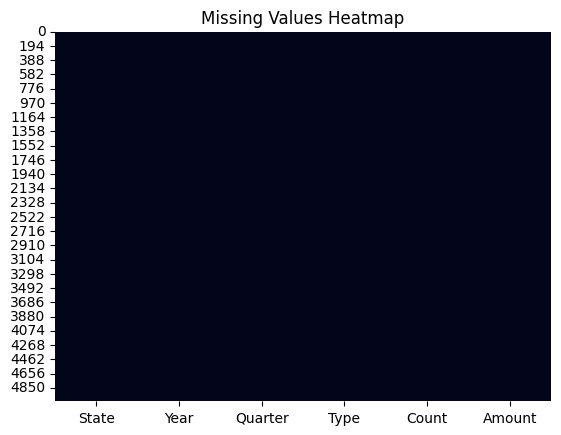

In [17]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset represents aggregated digital payment transactions across different states in India over multiple years and quarters. It includes key features such as transaction type, count, and total amount. The data is well-structured, with minimal missing or duplicate values, making it suitable for exploratory data analysis. Initial observations indicate that transaction amounts vary significantly across states and show an increasing trend over time, reflecting the growth of digital payments.

## ***2. Understanding Your Variables***

In [18]:
# Dataset Columns
df.columns

Index(['State', 'Year', 'Quarter', 'Type', 'Count', 'Amount'], dtype='object')

In [19]:
# Dataset Describe
df.describe()

,Year,Quarter,Count,Amount
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03
mean,2021.002582,2.500795,4.673902e+07,6.863772e+10
std,1.999849,1.118145,1.690968e+08,2.685200e+11
min,2018.000000,1.000000,2.000000e+00,3.439721e+01
25%,2019.000000,2.000000,5.808950e+04,3.993888e+07
50%,2021.000000,3.000000,5.158310e+05,4.394139e+08
75%,2023.000000,4.000000,1.166629e+07,1.102822e+10
max,2024.000000,4.000000,2.393918e+09,3.095666e+12


### Variables Description

#### The dataset consists of the following variables:

#### State: Represents the name of the state where transactions occurred.
#### Year: Indicates the year in which the transactions were recorded.
#### Quarter: Represents the quarter of the year (1 to 4).
#### Type: Denotes the category of transaction (e.g., Peer-to-peer, Recharge, etc.).
#### Count: Number of transactions performed.
#### Amount: Total transaction value in rupees.

### Check Unique Values for each variable.

In [20]:
# Check Unique Values for each variable.
for col in df.columns:
    print(col, ":", df[col].nunique())

State : 36
Year : 7
Quarter : 4
Type : 5
Count : 4966
Amount : 5034


## 3. ***Data Wrangling***

### Data Wrangling Code

In [21]:
# Write your code to make your dataset analysis ready.

# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

# Convert data types (if needed)
df["Year"] = df["Year"].astype(int)
df["Quarter"] = df["Quarter"].astype(int)
df["Amount"] = df["Amount"].astype(float)
df["Count"] = df["Count"].astype(int)

# Check final dataset
df.info()

Duplicates: 0
State      0
Year       0
Quarter    0
Type       0
Count      0
Amount     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   State    5034 non-null   object 
 1   Year     5034 non-null   int64  
 2   Quarter  5034 non-null   int64  
 3   Type     5034 non-null   object 
 4   Count    5034 non-null   int64  
 5   Amount   5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB


### What all manipulations have you done and insights you found?

In the data wrangling phase, several preprocessing steps were performed to prepare the dataset for analysis. Initially, the dataset was checked for duplicate values, and any duplicates found were removed to ensure data accuracy. The dataset was also examined for missing or null values, and it was observed that there were no significant missing entries, indicating good data quality.

Data types of relevant columns such as Year, Quarter, Count, and Amount were verified and converted to appropriate numerical formats to enable efficient analysis. Additionally, the dataset was structured properly to ensure consistency across all variables.

Overall, the dataset was found to be clean, well-organized, and suitable for exploratory data analysis and visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [22]:
# Chart - 1 visualization code
import plotly.express as px

top_states = df.groupby("State")["Amount"].sum().reset_index()
top_states = top_states.sort_values(by="Amount", ascending=False).head(10)

fig = px.bar(top_states, x="State", y="Amount",
             title="Top 10 States by Transaction Amount")

fig.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it is effective for comparing values across different categories. In this case, it helps to clearly visualize and compare the transaction amounts across different states, making it easy to identify the top-performing regions.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that a few states contribute significantly to the total transaction amount, indicating uneven distribution of digital payment adoption. States like Maharashtra, Karnataka, and Telangana dominate in terms of transaction value, suggesting higher digital payment usage and economic activity in these regions. This highlights regional disparities in digital payment adoption.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights gained from this chart can help businesses and policymakers focus on high-performing regions to maximize returns while also identifying underperforming states where digital adoption can be improved through targeted strategies.

There are no strong indications of negative growth from this chart; however, lower transaction values in certain states suggest slower adoption of digital payments, which could be due to lack of awareness, infrastructure, or accessibility. Addressing these gaps can lead to increased growth and wider digital inclusion.

#### Chart - 2

In [23]:
# Chart - 2 visualization code
import plotly.express as px

year_trend = df.groupby("Year")["Amount"].sum().reset_index()

fig = px.line(year_trend, x="Year", y="Amount",
              title="Year-wise Transaction Growth",
              markers=True)

fig.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because it is the most suitable visualization for analyzing trends over time. It helps in clearly understanding how transaction amounts have changed across different years and allows easy identification of growth patterns.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a steady and significant increase in transaction amounts over the years, indicating rapid growth in digital payment adoption. This trend reflects increasing user trust, improved digital infrastructure, and wider acceptance of online payment systems. The consistent upward trend suggests that digital transactions are becoming an integral part of everyday financial activities.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The observed growth trend has a strong positive business impact, as it indicates increasing market potential for digital payment platforms. Businesses can leverage this growth by expanding services, improving user experience, and introducing new features to retain users.

There are no signs of negative growth in the trend, which highlights the stability and continuous expansion of digital payment adoption. However, any slowdown in growth in certain periods may indicate market saturation or external factors, which businesses should monitor closely.

#### Chart - 3

In [24]:
# Chart - 3 visualization code
import plotly.express as px

category_data = df.groupby("Type")["Amount"].sum().reset_index()

fig = px.pie(category_data, names="Type", values="Amount",
             title="Transaction Category Distribution")

fig.show()

##### 1. Why did you pick the specific chart?

A pie chart was chosen because it is effective for representing the proportion of different categories within a whole. It helps in understanding how transaction amounts are distributed across various transaction types, making it easy to identify dominant categories.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that certain transaction categories, such as peer-to-peer payments and merchant payments, contribute the largest share of total transaction value. This indicates that users primarily rely on digital platforms for everyday transfers and payments. Other categories like recharges and bill payments contribute comparatively less, highlighting differences in user behavior across transaction types.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These insights can help businesses focus on the most widely used transaction categories to improve services and introduce targeted features. For example, enhancing peer-to-peer payment experience or offering incentives in high-usage categories can increase user engagement.

Categories with lower contribution may indicate untapped opportunities or areas requiring better awareness and accessibility. There is no strong negative growth observed, but lower-performing categories suggest potential areas for improvement and expansion.

#### Chart - 4

In [25]:
# Chart - 4 visualization code
import plotly.express as px

quarter_data = df.groupby(["Year", "Quarter"])["Amount"].sum().reset_index()

fig = px.line(quarter_data, x="Quarter", y="Amount", color="Year",
              title="Quarter-wise Transaction Trend Across Years",
              markers=True)

fig.show()

##### 1. Why did you pick the specific chart?

A multi-line chart was chosen to compare transaction trends across different quarters for multiple years simultaneously. This visualization helps in identifying seasonal patterns and variations in transaction behavior within each year.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals that transaction amounts generally increase across quarters within a year, indicating progressive growth. Additionally, each year shows higher transaction values compared to the previous year, reinforcing the overall growth trend in digital payments. Some quarters may show sharper increases, suggesting possible seasonal effects such as festivals or increased economic activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding quarterly trends helps businesses plan strategies around peak periods. For example, companies can introduce offers, cashback, or marketing campaigns during high-transaction quarters to maximize engagement.

There is no clear negative growth observed, but relatively lower activity in certain quarters may indicate periods of reduced user engagement. Businesses can use this insight to design targeted campaigns to boost activity during slower periods.

#### Chart - 5

In [26]:
# Chart - 5 visualization code
import plotly.express as px

fig = px.scatter(df, x="Count", y="Amount", color="Type",
                 title="Relationship between Transaction Count and Amount")

fig.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to analyze the relationship between transaction count and transaction amount. It helps in identifying patterns, correlations, and variations across different transaction types.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a positive relationship between transaction count and transaction amount, indicating that as the number of transactions increases, the total transaction value also increases. However, different transaction types exhibit varying patterns, suggesting that some categories involve higher-value transactions with fewer counts, while others involve frequent but smaller transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight helps businesses understand customer behavior across transaction types. High-frequency, low-value transactions may indicate everyday usage, while low-frequency, high-value transactions may represent premium or large payments.

There are no negative growth patterns observed, but variations across categories highlight opportunities to optimize pricing strategies, transaction limits, or incentives based on user behavior.

#### Chart - 6

In [27]:
# Chart - 6 visualization code
import plotly.express as px

# Get top 5 states
top_states = df.groupby("State")["Amount"].sum().nlargest(5).index

# Filter data
filtered_df = df[df["State"].isin(top_states)]

# Group data
state_type = filtered_df.groupby(["State", "Type"])["Amount"].sum().reset_index()

fig = px.bar(state_type, x="State", y="Amount", color="Type",
             title="Transaction Types Distribution in Top States",
             barmode="group")

fig.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was chosen to compare multiple transaction categories across top-performing states. This helps in understanding how transaction behavior differs between states and across different transaction types.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that even among top-performing states, the contribution of different transaction types varies. While some states have higher peer-to-peer transactions, others show stronger merchant payment activity. This indicates that user behavior is not uniform and depends on regional usage patterns and economic activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight is valuable for businesses aiming to design region-specific strategies. Companies can customize offers, incentives, and features based on dominant transaction types in each state.

There are no signs of negative growth, but variation across states suggests that some regions may not be fully utilizing certain transaction types, presenting opportunities for targeted expansion and awareness campaigns.

#### Chart - 7

In [28]:
# Chart - 7 visualization code
import plotly.express as px

state_count = df.groupby("State")["Count"].sum().reset_index()
state_count = state_count.sort_values(by="Count", ascending=False).head(10)

fig = px.bar(state_count, x="State", y="Count",
             title="Top 10 States by Transaction Count")

fig.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare the number of transactions across different states. While previous charts focused on transaction value, this chart highlights transaction frequency, providing another perspective on user activity.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that certain states have a high number of transactions, indicating strong user engagement and frequent usage of digital payment platforms. Interestingly, some states with high transaction counts may not necessarily have the highest transaction amounts, suggesting the presence of many small-value transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight helps businesses understand user behavior more clearly. States with high transaction counts represent active user bases and are ideal for introducing new features or services.

On the other hand, states with lower transaction counts may require awareness campaigns or incentives to increase adoption. There is no negative growth observed, but lower engagement in some regions indicates potential areas for expansion.

#### Chart - 8

In [29]:
# Chart - 8 visualization code
import plotly.express as px

# Create new column
df["Avg_Transaction_Value"] = df["Amount"] / df["Count"]

avg_state = df.groupby("State")["Avg_Transaction_Value"].mean().reset_index()
avg_state = avg_state.sort_values(by="Avg_Transaction_Value", ascending=False).head(10)

fig = px.bar(avg_state, x="State", y="Avg_Transaction_Value",
             title="Top 10 States by Average Transaction Value")

fig.show()

##### 1. Why did you pick the specific chart?

This chart was chosen to analyze the average value per transaction, which provides deeper insight into user spending behavior. Unlike total amount or count, this metric helps understand whether users are making high-value or low-value transactions.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some states have higher average transaction values, indicating that users in these regions tend to perform higher-value transactions. In contrast, other states may have lower average values, suggesting frequent but smaller transactions. This highlights differences in spending patterns across regions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight is valuable for designing pricing strategies, transaction limits, and targeted financial products. States with higher average transaction values may be ideal for premium services, while states with lower values may benefit from incentives to increase transaction size.

There is no negative growth observed, but variations in average transaction values indicate opportunities for businesses to tailor their offerings based on regional behavior.

#### Chart - 9

In [30]:
# Chart - 9 visualization code
import plotly.express as px

# Year-wise total amount
year_data = df.groupby("Year")["Amount"].sum().reset_index()

# Calculate growth %
year_data["Growth_%"] = year_data["Amount"].pct_change() * 100

fig = px.bar(year_data, x="Year", y="Growth_%",
             title="Year-on-Year Growth Rate (%) of Transactions")

fig.show()

##### 1. Why did you pick the specific chart?

This chart was chosen to analyze the growth rate of digital transactions over time. Instead of just showing total values, it highlights the percentage increase year-over-year, providing a clearer understanding of how rapidly digital payments are expanding.

##### 2. What is/are the insight(s) found from the chart?

The chart shows positive growth in most years, indicating consistent expansion in digital payment adoption. Some years may exhibit higher growth rates, reflecting periods of rapid digital transformation and increased user adoption. The overall trend confirms that digital transactions are growing at a strong pace.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding growth rate helps businesses and policymakers assess market momentum. High growth periods indicate strong opportunities for expansion, while slower growth may signal market maturity or the need for innovation.

There are no major negative growth phases observed, suggesting stable and continuous development in the digital payments ecosystem.

#### Chart - 10

In [31]:
# Chart - 10 visualization code
import plotly.express as px

# Get top 5 states (to keep chart clean)
top_states = df.groupby("State")["Amount"].sum().nlargest(5).index

filtered_df = df[df["State"].isin(top_states)]

state_year = filtered_df.groupby(["Year", "State"])["Amount"].sum().reset_index()

fig = px.line(state_year, x="Year", y="Amount", color="State",
              title="State-wise Transaction Growth Over Time",
              markers=True)

fig.show()

##### 1. Why did you pick the specific chart?

A multi-line chart was chosen to compare the growth of transaction amounts across different states over time. This helps in understanding how digital payment adoption varies regionally and how different states contribute to overall growth.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that all top states exhibit a consistent upward trend in transaction amounts, indicating strong and steady growth in digital payment usage. However, the rate of growth differs across states, suggesting variations in adoption speed and economic activity. Some states show sharper increases, indicating faster digital transformation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight enables businesses to identify high-growth regions and prioritize investments accordingly. States with faster growth can be targeted for expansion, partnerships, and premium services.

Slower-growing states may require awareness campaigns or infrastructure improvements to boost adoption. There is no negative growth observed, indicating a stable and expanding digital payment ecosystem across regions.

#### Chart - 11

In [32]:
# Chart - 11 visualization code
import os
import json
import pandas as pd
import plotly.express as px

# Path for district data
path_map = "/content/drive/MyDrive/pulse/data/map/transaction/hover/country/india/state"

district_list = []

for state in os.listdir(path_map):
    state_path = os.path.join(path_map, state)

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):
            file_path = os.path.join(year_path, file)

            with open(file_path, "r") as f:
                data = json.load(f)

                for i in data["data"]["hoverDataList"]:
                    district_list.append({
                        "State": state,
                        "Year": int(year),
                        "Quarter": int(file.strip(".json")),
                        "District": i["name"],
                        "Amount": i["metric"][0]["amount"]
                    })

# Create DataFrame
df_district = pd.DataFrame(district_list)

# Top districts
top_districts = df_district.groupby("District")["Amount"].sum().reset_index()
top_districts = top_districts.sort_values(by="Amount", ascending=False).head(10)

# Plot
fig = px.bar(top_districts, x="District", y="Amount",
             title="Top 10 Districts by Transaction Amount")

fig.show()

##### 1. Why did you pick the specific chart?

This chart was chosen to analyze transaction patterns at a more granular level by focusing on districts rather than states. It helps in identifying localized regions with high digital payment activity, providing deeper insights into regional behavior.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that certain districts contribute significantly to transaction volumes, indicating concentrated digital payment activity in specific regions. These districts likely represent urban or economically active areas with higher digital adoption. This highlights the uneven distribution of digital payment usage even within states.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight is valuable for businesses and policymakers to identify high-potential districts for expansion and targeted services. Companies can focus on these areas for marketing campaigns, partnerships, and premium offerings.

Districts with lower transaction activity may require infrastructure development or awareness programs to improve adoption. This helps in achieving balanced digital growth across regions.

#### Chart - 12

In [33]:
# Chart - 12 visualization code
import plotly.express as px

# Create pivot table
heatmap_data = df.pivot_table(values="Amount", index="State", columns="Year", aggfunc="sum")

# Optional: take top 10 states for clarity
top_states = df.groupby("State")["Amount"].sum().nlargest(10).index
heatmap_data = heatmap_data.loc[top_states]

fig = px.imshow(heatmap_data,
                title="State vs Year Transaction Heatmap",
                labels=dict(x="Year", y="State", color="Amount"))

fig.show()

##### 1. Why did you pick the specific chart?

A heatmap was chosen to visualize the intensity of transaction amounts across states and years. It provides a compact and intuitive way to identify patterns, trends, and variations across multiple dimensions simultaneously.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that transaction amounts increase consistently over the years for most states, with darker shades indicating higher values. It highlights that certain states consistently perform better across all years, while others show gradual improvement. This clearly reflects both growth trends and regional differences in digital payment adoption.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This visualization helps businesses identify consistently high-performing states and track growth patterns over time. It allows better strategic planning by focusing on strong regions while also identifying states that are improving and may offer future opportunities.

There is no indication of negative growth, but lighter areas in the heatmap suggest regions with lower adoption, where targeted efforts can help boost digital payment usage.

#### Chart - 13

In [34]:
# Chart - 13 visualization code
import plotly.express as px

type_year = df.groupby(["Year", "Type"])["Amount"].sum().reset_index()

fig = px.line(type_year, x="Year", y="Amount", color="Type",
              title="Transaction Type Growth Over Time",
              markers=True)

fig.show()

##### 1. Why did you pick the specific chart?

A multi-line chart was chosen to compare the growth of different transaction types over time. It helps in understanding how various categories contribute to overall digital payment growth and how their usage evolves across years.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that all transaction types exhibit an upward trend over time, indicating overall growth in digital payments. However, some categories grow faster than others, highlighting shifts in user preferences and increasing reliance on specific types of transactions such as peer-to-peer and merchant payments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight helps businesses identify which transaction categories are growing rapidly and require more focus. Companies can invest in improving high-growth categories and introduce new features or incentives to enhance user experience.

Slower-growing categories may need targeted strategies to increase adoption. Overall, the chart indicates a positive growth trend with no major decline in any category.

#### Chart - 14 - Correlation Heatmap

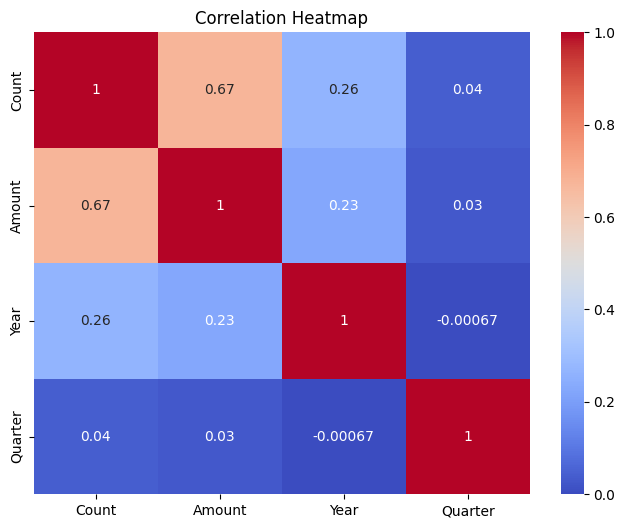

In [35]:
# Correlation Heatmap visualization code
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
corr_data = df[["Count", "Amount", "Year", "Quarter"]]

# Compute correlation
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen to understand the relationships between numerical variables in the dataset. It helps in identifying how strongly variables such as transaction count, amount, year, and quarter are related to each other.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows a strong positive correlation between transaction count and transaction amount, indicating that higher transaction volumes are associated with higher total values. Additionally, there is a positive correlation between year and transaction amount, suggesting consistent growth in digital payments over time. Quarter-wise correlation is relatively weaker, indicating that seasonal variations are less significant compared to overall yearly growth.

#### Chart - 15 - Pair Plot

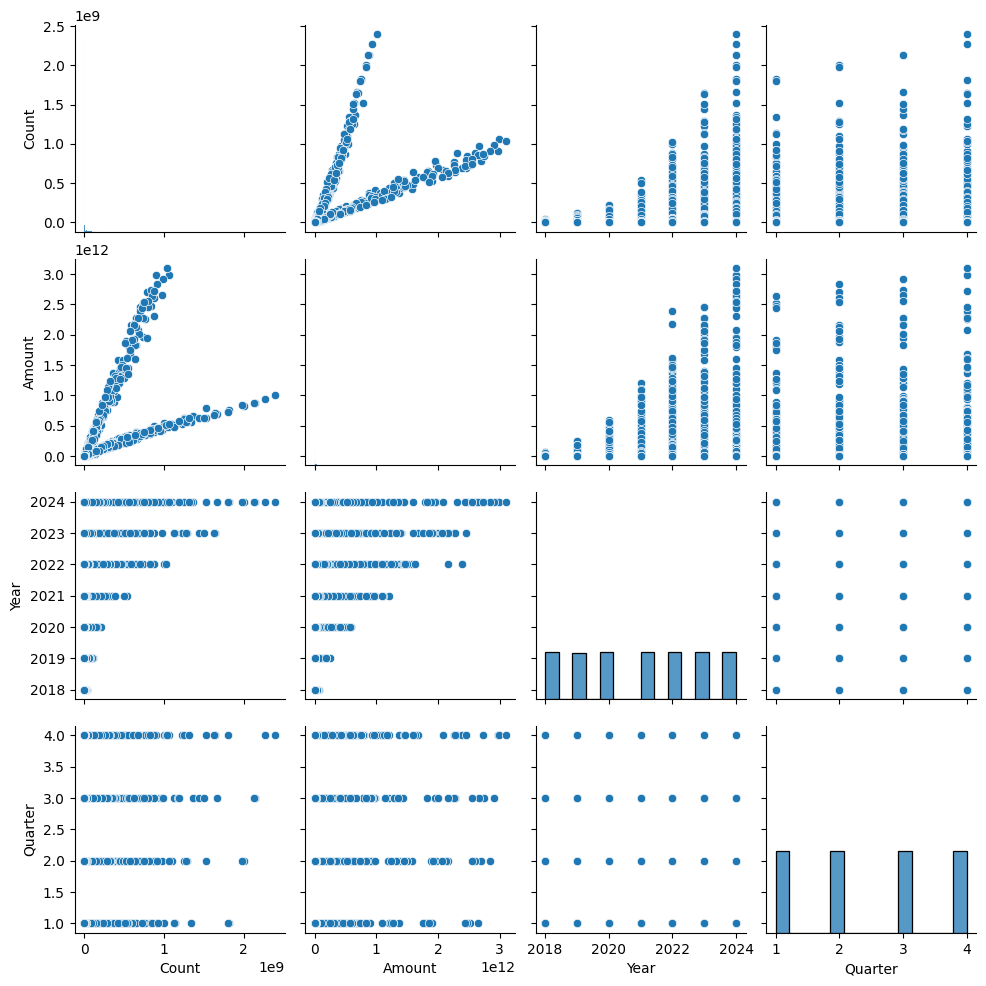

In [36]:
# Pair Plot visualization code
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
pair_data = df[["Count", "Amount", "Year", "Quarter"]]

sns.pairplot(pair_data)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize the relationships between multiple numerical variables simultaneously. It provides both scatter plots and distribution plots, making it useful for identifying patterns, correlations, and data distributions in a single view.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows a clear positive relationship between transaction count and transaction amount, confirming that higher transaction frequency leads to higher total value. The distribution plots indicate that transaction data is skewed, with a large number of lower-value transactions and fewer high-value transactions. Additionally, the relationship between year and transaction amount suggests a consistent upward trend over time.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis of PhonePe transaction data, it is recommended that businesses and policymakers focus on expanding digital payment adoption in underperforming regions while strengthening services in high-performing areas.

High-transaction states should be prioritized for introducing advanced features, premium services, and partnerships to maximize revenue. At the same time, states and districts with lower transaction activity require targeted awareness campaigns, improved digital infrastructure, and user incentives to increase adoption.

Additionally, businesses should focus on the most widely used transaction categories, such as peer-to-peer and merchant payments, to enhance user experience and engagement. Monitoring transaction trends and growth patterns can help in making data-driven decisions and planning future strategies effectively.

# **Conclusion**

This project focused on analyzing PhonePe transaction data to understand digital payment trends across different states, years, and transaction categories. Through data cleaning, transformation, and exploratory data analysis, meaningful insights were derived regarding transaction growth, regional distribution, and user behavior.

The analysis revealed a consistent increase in digital payment adoption over time, with certain states contributing significantly to overall transaction volume. It also highlighted variations in transaction patterns across regions and categories, indicating differences in user preferences and economic activity.

Various visualizations were used to uncover trends, relationships, and patterns in the dataset, providing a comprehensive understanding of the digital payments landscape. The findings from this project can help businesses and policymakers make informed decisions to improve digital payment adoption and optimize their strategies.

Overall, the project demonstrates the power of data analysis in extracting valuable insights and supporting data-driven decision-making in the financial technology domain.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***